In [2]:
# Importamos las librerías base para conexión (requests) y estructuración (bs4)
import requests
from bs4 import BeautifulSoup
from requests.exceptions import HTTPError
texto_limpio_pagina=""
respuesta = None

In [3]:
# funcion para buscar una palabra en el texto limpio de la página
def buscar_palabra(palabra):
  ocurrencias = texto_limpio_pagina.count(palabra.lower())
  print(f"Encontraste la palabra '{palabra}' {ocurrencias} veces")


In [4]:

url = 'https://www.bbc.com/mundo/articles/c3v6yn213eno'

try:
    respuesta = requests.get(url)
    
    # Si el código no es 200-299, lanza una excepción HTTPError
    respuesta.raise_for_status()
    
    # Si llegamos acá, la petición fue exitosa
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    #datos = respuesta.json()
    print("¡Conexión exitosa!")
    #print(datos)

except HTTPError as error_http:
    print(f"Ocurrió un error HTTP: {error_http}")
    print(respuesta.status_code )
    #print(f"Código de estado: {error_http.response.status_code}")
    if respuesta.status_code == 404:
        print("La página no existe.")
    elif respuesta.status_code == 500:
        print("El servidor está caído.")

except Exception as otro_error:
    print(f"Código de estado: {respuesta.status_code}")
    print(f"Ocurrió otro error (conexión, timeout, etc.): {otro_error}")

¡Conexión exitosa!


In [5]:
parrafos = soup.find_all("p")
print(f"Encontramos {len(parrafos)} parrafos.")

from collections import Counter

# Extraemos el texto visible de toda la página limpiando el HTML con get_text()
texto_limpio_pagina = soup.get_text().lower()

buscar_palabra("iran")
buscar_palabra("embarcaciones")
buscar_palabra("reapertura")
buscar_palabra("ormuz")

import random
parrafo_aleatorio = random.choice(parrafos).text.strip()

print("\nLee un pasaje aleatorio de articulo de la BBC")
print("-----------------------------------------------")
print(parrafo_aleatorio)
print("-----------------------------------------------")
print(f"Este párrafo tiene {len(parrafo_aleatorio.split())} palabras.")


Encontramos 59 parrafos.
Encontraste la palabra 'iran' 3 veces
Encontraste la palabra 'embarcaciones' 5 veces
Encontraste la palabra 'reapertura' 9 veces
Encontraste la palabra 'ormuz' 21 veces

Lee un pasaje aleatorio de articulo de la BBC
-----------------------------------------------
Menos de 24 horas después de anunciar la reapertura del estrecho de Ormuz, Irán ha informado que ha vuelto a cerrar la ruta por donde transita alrededor del 20% del crudo que consume el mundo.
-----------------------------------------------
Este párrafo tiene 35 palabras.


In [6]:
# aplicamos herramientas de filtrado.

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re

# Descargamos las stopwords en español silenciosamente
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('spanish'))

In [7]:
# Función para limpiar y tokenizar el texto final
def depurar_texto(texto):
    texto_minusculas = texto.lower()
    # Limitamos los carácteres (borramos puntuación usando regex)
    texto_sin_puntuacion = re.sub(r'[^\w\s]', '', texto_minusculas)
    lista_palabras = texto_sin_puntuacion.split()

    palabras_importantes = []
    for palabra in lista_palabras:
        if palabra not in stop_words:
            palabras_importantes.append(palabra)

    return palabras_importantes

# Obtener otra vez el texto completo
texto_completo = soup.get_text()
palabras_limpias = depurar_texto(texto_completo)

# Reensamblamos todo en un string global con espacios
texto_limpio = ' '.join(palabras_limpias)

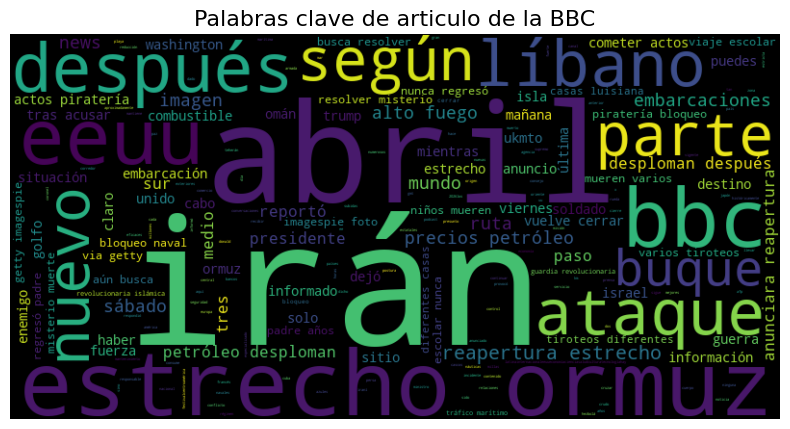

In [8]:
# Nube de palabras de articulo de la BBC
wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      stopwords=stop_words,
                      contour_width=3,
                      contour_color='steelblue').generate(texto_limpio)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras clave de articulo de la BBC', fontsize=16)
plt.show()

In [9]:
# Añadimos palabras que no aportan valor semántico al conjunto (set) de stopwords
palabras_extra = ["si", "así", "pues", "bien", "cómo", "aún", "tal", "ser", "dijo", "respondió", "á", "irán"]
stop_words.update(palabras_extra)

# Volvemos a depurar el texto base original con las nuevas reglas
palabras_limpias_iteracion = depurar_texto(texto_completo)
texto_limpio_iteracion = ' '.join(palabras_limpias_iteracion)

print(f"El texto original tenía {len(texto_completo.split())} palabras.")
print(f"En esta iteración nos quedamos con {len(palabras_limpias_iteracion)} palabras clave.")

El texto original tenía 2215 palabras.
En esta iteración nos quedamos con 1231 palabras clave.


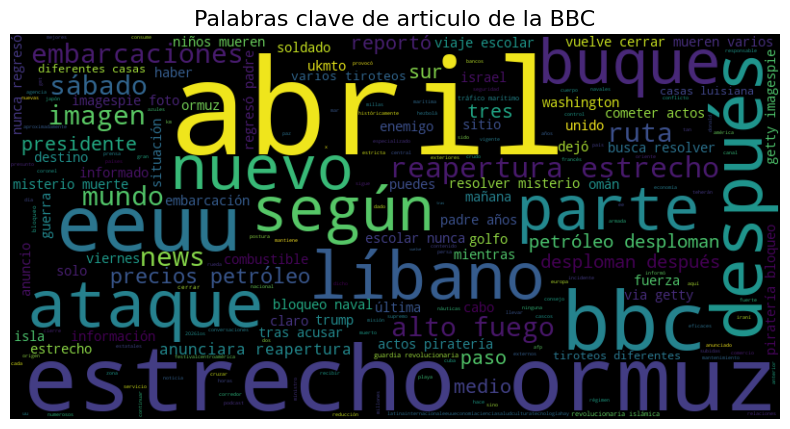

In [10]:
# Nube de palabras de articulo de la BBC
wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      stopwords=stop_words,
                      contour_width=3,
                      contour_color='steelblue').generate(texto_limpio)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras clave de articulo de la BBC', fontsize=16)
plt.show()